In [1]:
library(tidyverse)
players <- read_csv("players (4).csv")
sessions <- read_csv("sessions (6).csv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimite

In [2]:
dim(players)
dim(sessions)

[1] 196   7

[1] 1535    5

<h3>1. Data Description</h3>

This project uses data collected from a Minecraft research server designed to study player behaviour. Two datasets are provided: players.csv, which contains demographic and background information about each player, and sessions.csv, which records gameplay sessions for those players. When merged, these datasets allow analysis of how demographic and behavioural characteristics relate to newsletter subscription.


**players.csv**

This dataset contains one row per unique player.

Number of observations: 196

Number of variables: 7


| Variable Name   | Type      | Meaning                                       |
|-----------------|-----------|-----------------------------------------------|
| experience      | character | Player’s self-reported skill level            |
| subscribe       | logical   | Whether the player subscribed (TRUE/FALSE)    |
| hashedEmail     | character | Anonymous unique player identifier            |
| played_hours    | numeric   | Total Minecraft hours played                  |
| name            | character | Player name                                   |
| gender          | character | Player gender                                 |
| Age             | numeric   | Player age                                    |

**sessions.csv**
This dataset contains one row per gameplay session. A single player may have many sessions.

Number of observations: 1535

Number of variables: 5

| Variable Name         | Type      | Meaning                                  |
|-----------------------|-----------|------------------------------------------|
| hashedEmail           | character | Links session to player                  |
| start_time            | datetime  | Session start                            |
| end_time              | datetime  | Session end                              |
| original_start_time   | datetime  | Original logged start time               |
| original_end_time     | datetime  | Original logged end time                 |


**Potential Data Issues**

- Missing age values for some players

- Players with no recorded sessions → NA after merging

- Some sessions have extremely long durations (possible idle time)

- Newsletter subscription is imbalanced (few 1’s)

- Behaviour data may not reflect true engagement (AFK)

- Time zone differences may influence session timing

In [4]:
players %>% summarise(across(where(is.numeric), ~ round(mean(.x, na.rm = TRUE), 2)))

played_hours,Age
<dbl>,<dbl>
5.85,21.14


<h3>2. Questions</h3>

**Broad Question**:
What player characteristics and behaviours are predictive of newsletter subscription?

**Specific Question**:
Can a player’s age and average session length be used to predict whether they subscribe to the newsletter?

Newsletter subscription is a binary variable, meaning players either subscribe or do not subscribe. This type of outcome can be modeled using classification methods, such as the k-nearest neighbours (KNN) algorithm covered in this course. KNN predicts an outcome based on the similarity between observations and is suitable for binary variables like subscription status. Age is available directly in the players dataset, while average session length can be computed from the sessions dataset by calculating the time difference between start_time and end_time, then averaging these durations for each player. Merging the two datasets using hashed_email creates a player-level table that combines demographic and behavioural information, allowing for analysis of how these factors relate to newsletter subscription.

played_hours,Age
<dbl>,<dbl>
5.85,21.14


Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 71 rows containing non-finite outside the scale range (`stat_bin()`).”


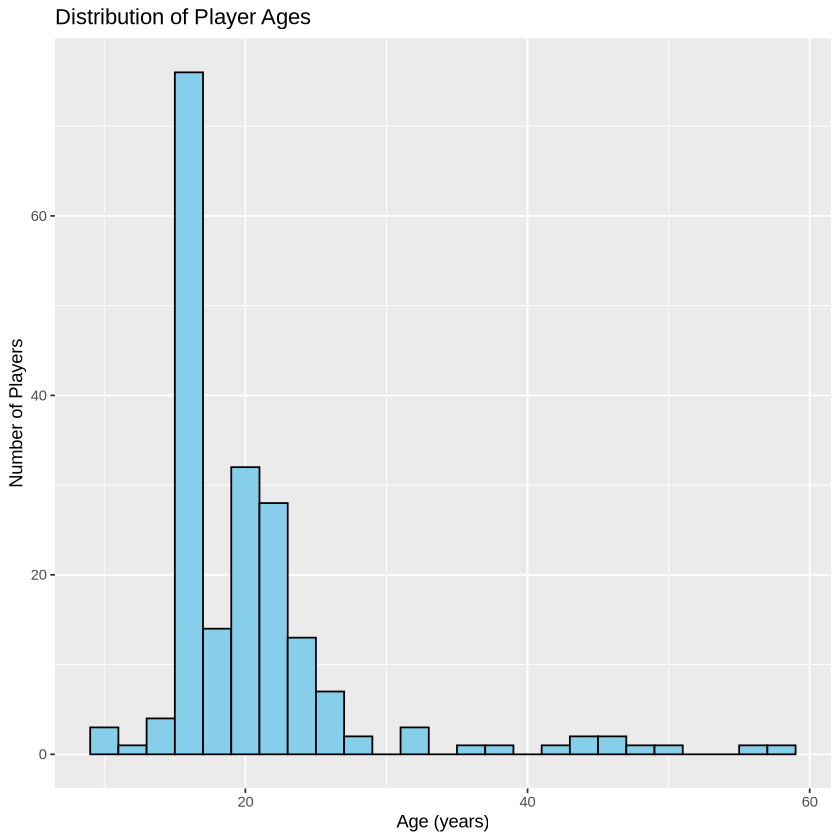

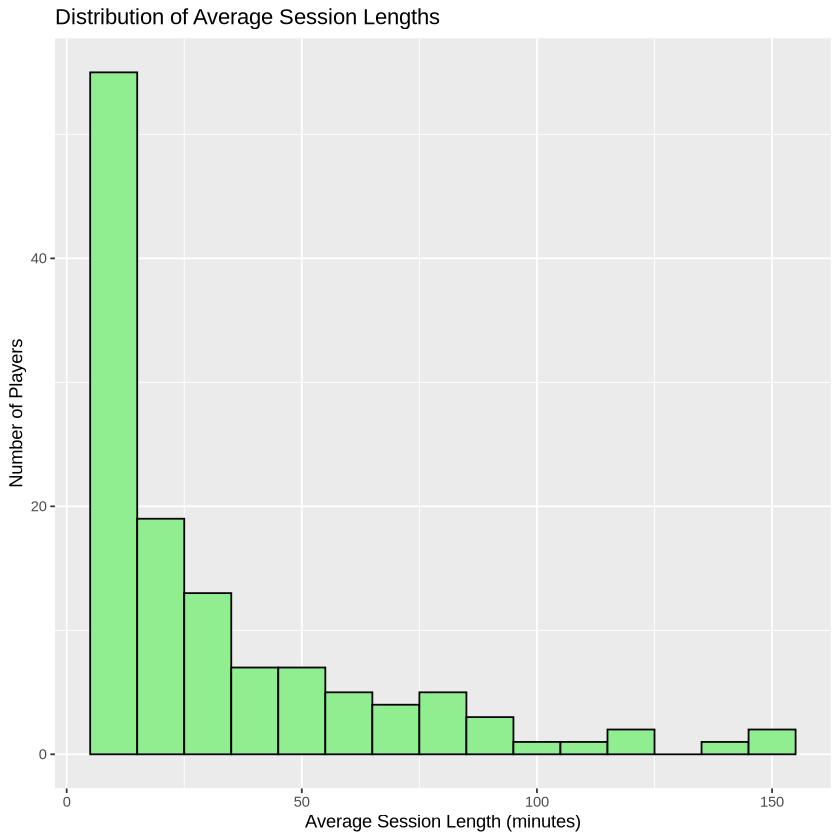

Warning message:
“Removed 71 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


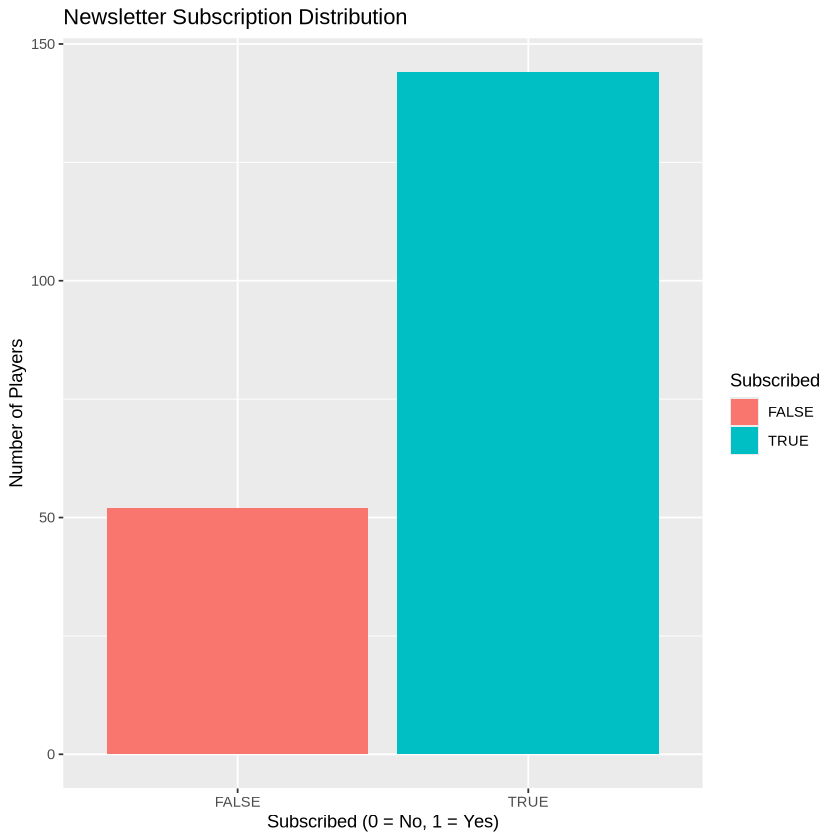

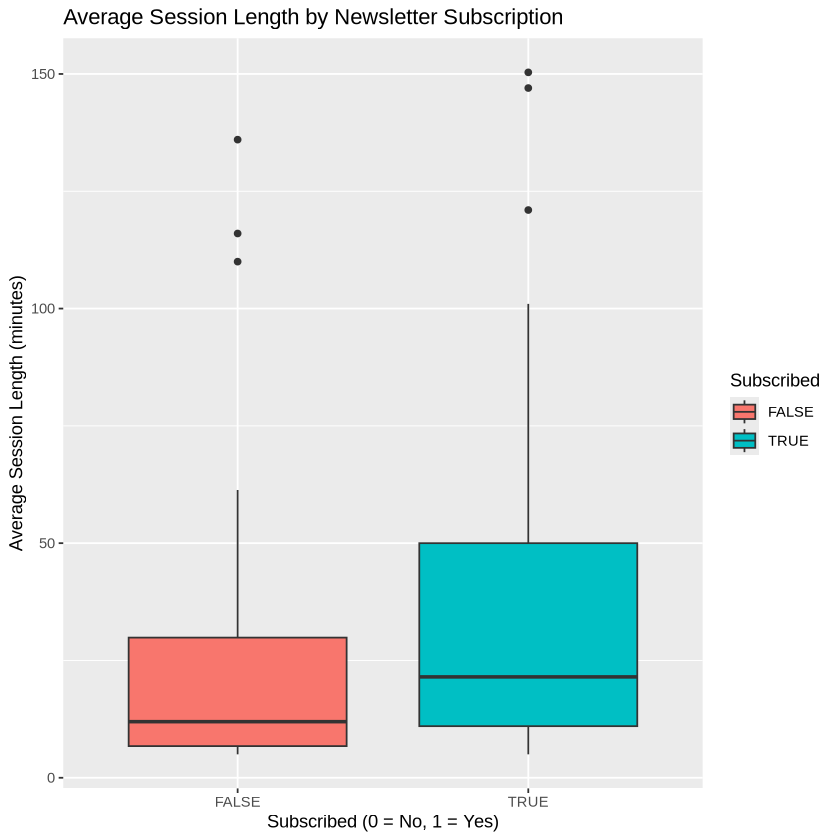

In [7]:

# Compute average session length per player
sessions_clean <- sessions %>%
  mutate(start_time = dmy_hm(start_time),
         end_time = dmy_hm(end_time),
         session_length = as.numeric(difftime(end_time, start_time, units = "mins"))) %>%
  group_by(hashedEmail) %>%
  summarise(avg_session_length = mean(session_length, na.rm = TRUE))

# Merge datasets
analysis_df <- players %>%
  left_join(sessions_clean, by = "hashedEmail")

# Summary stats
players %>%
  summarise(across(where(is.numeric), ~round(mean(.x, na.rm = TRUE), 2)))

# plots
ggplot(analysis_df, aes(x = Age)) +
  geom_histogram(binwidth = 2, fill = "skyblue", color = "black") +
  labs(title = "Distribution of Player Ages", x = "Age (years)", y = "Number of Players")

ggplot(analysis_df, aes(x = avg_session_length)) +
  geom_histogram(binwidth = 10, fill = "lightgreen", color = "black") +
  labs(title = "Distribution of Average Session Lengths", 
       x = "Average Session Length (minutes)", 
       y = "Number of Players")

ggplot(analysis_df, aes(x = as.factor(subscribe), fill = as.factor(subscribe))) +
  geom_bar() +
  labs(title = "Newsletter Subscription Distribution", 
       x = "Subscribed (0 = No, 1 = Yes)", 
       y = "Number of Players", 
       fill = "Subscribed")

ggplot(analysis_df, aes(x = as.factor(subscribe), y = avg_session_length, fill = as.factor(subscribe))) +
  geom_boxplot() +
  labs(title = "Average Session Length by Newsletter Subscription", 
       x = "Subscribed (0 = No, 1 = Yes)", 
       y = "Average Session Length (minutes)", 
       fill = "Subscribed")

The first graph shows that most players are between 15 and 25 years old, meaning the game mainly attracts younger players. Since most subscribers also fall into this range, age might not strongly separate who subscribes and who doesn’t — younger players make up most of both groups.

The second graph shows that most players have short play sessions, but a few spend much longer in the game. This helps show how engaged different players are and may connect to their interest in staying involved with updates like the newsletter.

The third graph shows that more players subscribed than didn’t, which means most people in the dataset are somewhat engaged. Knowing this helps understand the balance of the data for later steps.

The final graph compares average session length by subscription. It shows that subscribers usually have longer play sessions than non-subscribers. This supports the idea that more active players are also more likely to subscribe.

Together, these patterns suggest that average session length might be a stronger factor for newsletter subscription than age. This helps narrow down which variables could matter most when exploring the question further.

<h3>4. Methods and Planning</h3>

To answer my question, I plan to use the k-nearest neighbours (KNN) classification method. This method is appropriate because the response variable, subscribe, is binary — players either subscribed or did not. KNN works by finding the players that are most similar to a new player based on their features (in this case, age and average session length) and predicting the outcome based on the majority of those neighbours.

KNN assumes that similar players will have similar outcomes and that all predictors are measured on a scale where distance makes sense. It also assumes that the data has been properly scaled, since large differences in measurement units (like years versus minutes) can affect how distance is calculated.

Some weaknesses of KNN are that it can be sensitive to outliers and imbalanced data, and it can be slower with large datasets. It also doesn’t show how much each variable affects the outcome — it only predicts based on similarity.

To compare and select the model, I plan to use cross-validation to find the best value of k (the number of neighbours). I will split the data into 75% for training and 25% for testing, train the model on the training data, and test its performance using accuracy or classification error.

Before modelling, I will make sure the data is cleaned by removing missing values, checking for outliers, and scaling the numerical variables so that age and session length are on a similar scale.

<h3>5. GitHub Repository</h3>

The GitHub repository for my DSCI 100 Individual Planning Report is available here:

https://github.com/isabelleyan0921-code/Isabelle-Yan-Individual-Project.git